# Paper Figures — 3 Missing Figures

## Fig A — 4-Model Per-Class F1 Bar Chart

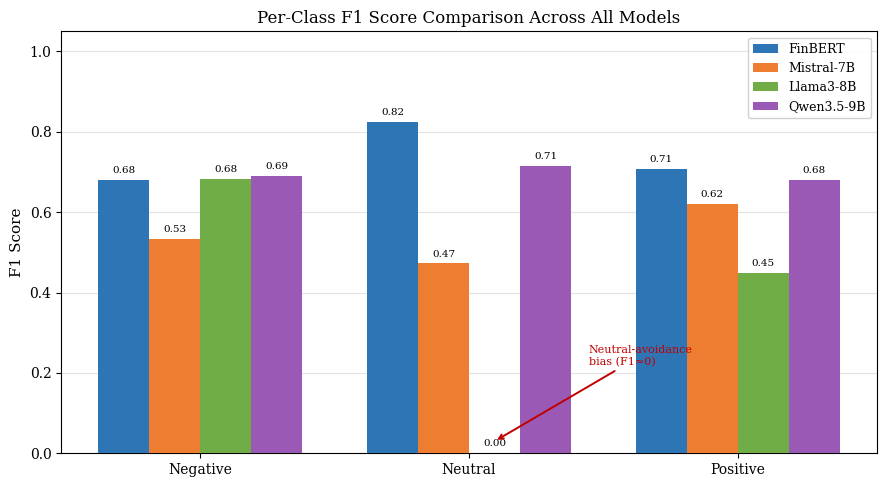

Fig A saved.


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

classes = ['Negative', 'Neutral', 'Positive']

finbert_f1  = [0.6806, 0.8242, 0.7072]
mistral_f1  = [0.5336, 0.4723, 0.6197]
llama3_f1   = [0.6819, 0.0007, 0.4479]
qwen3_f1    = [0.69,   0.7141, 0.68  ]   

x = np.arange(len(classes))
w = 0.19

colors = {
    'FinBERT':   '#2E75B6',
    'Mistral-7B':'#ED7D31',
    'Llama3-8B': '#70AD47',
    'Qwen3.5-9B':'#9B59B6',
}

fig, ax = plt.subplots(figsize=(9, 5))

b1 = ax.bar(x - 1.5*w, finbert_f1, w, label='FinBERT',    color=colors['FinBERT'],    zorder=3)
b2 = ax.bar(x - 0.5*w, mistral_f1, w, label='Mistral-7B', color=colors['Mistral-7B'], zorder=3)
b3 = ax.bar(x + 0.5*w, llama3_f1,  w, label='Llama3-8B',  color=colors['Llama3-8B'],  zorder=3)
b4 = ax.bar(x + 1.5*w, qwen3_f1,   w, label='Qwen3.5-9B', color=colors['Qwen3.5-9B'], zorder=3)

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        label = f'{h:.2f}' if h >= 0.01 else '0.00'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.012,
            label,
            ha='center', va='bottom', fontsize=7.5, rotation=0
        )

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score Comparison Across All Models')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.yaxis.grid(True, alpha=0.35, zorder=0)
ax.set_axisbelow(True)

ax.annotate(
    'Neutral-avoidance\nbias (F1≈0)',
    xy=(x[1] + 0.5*w, 0.03),
    xytext=(x[1] + 0.5*w + 0.35, 0.22),
    arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.4),
    fontsize=8, color='#C00000'
)

plt.tight_layout()
plt.savefig('fig_A_perclass_f1_4models.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig_A_perclass_f1_4models.png', dpi=300, bbox_inches='tight')
plt.show()
print('Fig A saved.')

## Fig B — 4-Model Neutral Class Bias Stacked Bar Chart

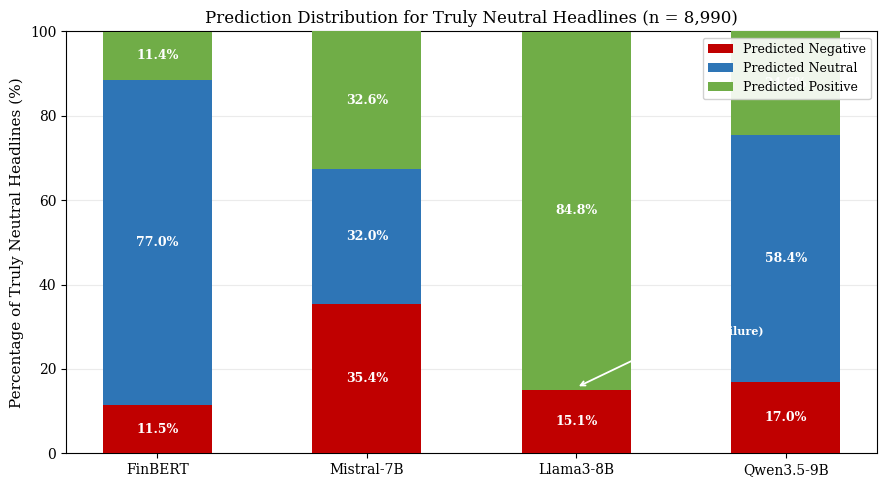

Fig B saved.


In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

models = ['FinBERT', 'Mistral-7B', 'Llama3-8B', 'Qwen3.5-9B']

neg_pct = [11.5, 35.4, 15.1, 17.0]
neu_pct = [77.0, 32.0,  0.0, 58.4]
pos_pct = [11.4, 32.6, 84.8, 24.6]

x = np.arange(len(models))
w = 0.52

neg_color = '#C00000'
neu_color = '#2E75B6'
pos_color = '#70AD47'

fig, ax = plt.subplots(figsize=(9, 5))

b1 = ax.bar(x, neg_pct, w, label='Predicted Negative', color=neg_color, zorder=3)
b2 = ax.bar(x, neu_pct, w, bottom=neg_pct,
            label='Predicted Neutral',  color=neu_color, zorder=3)
b3 = ax.bar(x, pos_pct, w,
            bottom=[n + u for n, u in zip(neg_pct, neu_pct)],
            label='Predicted Positive', color=pos_color, zorder=3)

def label_bar(ax, bars, bottoms, threshold=5):
    for bar, bot in zip(bars, bottoms):
        h = bar.get_height()
        if h >= threshold:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bot + h / 2,
                f'{h:.1f}%',
                ha='center', va='center',
                fontsize=9, color='white', fontweight='bold'
            )
        elif h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bot + h / 2,
                f'{h:.1f}%',
                ha='center', va='center',
                fontsize=7.5, color='white', fontweight='bold'
            )

label_bar(ax, b1, [0] * 4)
label_bar(ax, b2, neg_pct)
label_bar(ax, b3, [n + u for n, u in zip(neg_pct, neu_pct)])

ax.annotate(
    '0.0%\n(complete failure)',
    xy=(2, 15.1 + 0.5),
    xytext=(2.35, 28),
    arrowprops=dict(arrowstyle='->', color='white', lw=1.3),
    fontsize=8, color='white', fontweight='bold'
)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 100)
ax.set_ylabel('Percentage of Truly Neutral Headlines (%)')
ax.set_title('Prediction Distribution for Truly Neutral Headlines (n = 8,990)')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.yaxis.grid(True, alpha=0.25, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fig_B_neutral_bias_4models.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig_B_neutral_bias_4models.png', dpi=300, bbox_inches='tight')
plt.show()
print('Fig B saved.')

## Fig C — Few-Shot Prompting Summary (Accuracy + Neutral F1 side by side)

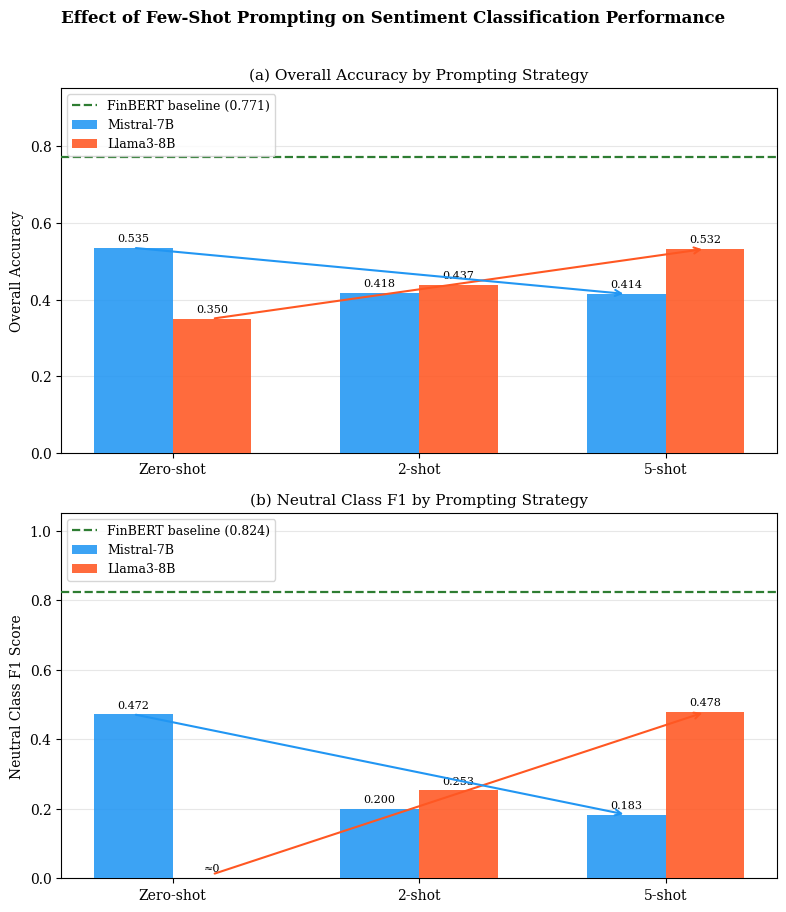

Fig C saved.


In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
})

shots = ['Zero-shot', '2-shot', '5-shot']
x = np.arange(len(shots))
w = 0.32

mistral_acc = [0.5347, 0.4179, 0.4145]
llama3_acc  = [0.3502, 0.4373, 0.5319]

mistral_neu_f1 = [0.472, 0.200, 0.183]
llama3_neu_f1  = [0.001, 0.253, 0.478]

finbert_acc_line    = 0.7712
finbert_neu_f1_line = 0.8242

mistral_col = '#2196F3'
llama3_col  = '#FF5722'

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

ax = axes[0]
bm = ax.bar(x - w/2, mistral_acc, w, label='Mistral-7B', color=mistral_col, alpha=0.88, zorder=3)
bl = ax.bar(x + w/2, llama3_acc,  w, label='Llama3-8B',  color=llama3_col,  alpha=0.88, zorder=3)
ax.axhline(finbert_acc_line, color='#2E7D32', linestyle='--', lw=1.6,
           label=f'FinBERT baseline ({finbert_acc_line:.3f})', zorder=4)

for bars in [bm, bl]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.012,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(shots)
ax.set_ylim(0, 0.95)
ax.set_ylabel('Overall Accuracy')
ax.set_title('(a) Overall Accuracy by Prompting Strategy')
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.grid(True, alpha=0.3, zorder=0)
ax.set_axisbelow(True)

ax.annotate('', xy=(x[2]+w/2, llama3_acc[2]), xytext=(x[0]+w/2, llama3_acc[0]),
            arrowprops=dict(arrowstyle='->', color=llama3_col, lw=1.5))
ax.annotate('', xy=(x[2]-w/2, mistral_acc[2]), xytext=(x[0]-w/2, mistral_acc[0]),
            arrowprops=dict(arrowstyle='->', color=mistral_col, lw=1.5))

ax = axes[1]
bm2 = ax.bar(x - w/2, mistral_neu_f1, w, label='Mistral-7B', color=mistral_col, alpha=0.88, zorder=3)
bl2 = ax.bar(x + w/2, llama3_neu_f1,  w, label='Llama3-8B',  color=llama3_col,  alpha=0.88, zorder=3)
ax.axhline(finbert_neu_f1_line, color='#2E7D32', linestyle='--', lw=1.6,
           label=f'FinBERT baseline ({finbert_neu_f1_line:.3f})', zorder=4)

for bars in [bm2, bl2]:
    for bar in bars:
        h = bar.get_height()
        label = f'{h:.3f}' if h >= 0.01 else '≈0'
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.012,
                label, ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(shots)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Neutral Class F1 Score')
ax.set_title('(b) Neutral Class F1 by Prompting Strategy')
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.grid(True, alpha=0.3, zorder=0)
ax.set_axisbelow(True)

ax.annotate('', xy=(x[2]+w/2, llama3_neu_f1[2]), xytext=(x[0]+w/2, llama3_neu_f1[0]+0.01),
            arrowprops=dict(arrowstyle='->', color=llama3_col, lw=1.5))
ax.annotate('', xy=(x[2]-w/2, mistral_neu_f1[2]), xytext=(x[0]-w/2, mistral_neu_f1[0]),
            arrowprops=dict(arrowstyle='->', color=mistral_col, lw=1.5))

plt.suptitle('Effect of Few-Shot Prompting on Sentiment Classification Performance',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_C_fewshot_summary.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig_C_fewshot_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print('Fig C saved.')

## Qwen3 Agreement Percentages

In [4]:
import pandas as pd

df_eval = pd.read_csv('sentiment_qwen3_eval.csv')   
df_final = pd.read_csv('sentiment_final.csv')        

qwen3_pred   = df_eval['qwen3_pred'].reset_index(drop=True)
finbert_pred = df_final['finbert_pred'].reset_index(drop=True)
mistral_pred = df_final['mistral_pred'].reset_index(drop=True)
llama3_pred  = df_final['llama3_pred'].reset_index(drop=True)

agree_fb = (qwen3_pred == finbert_pred).mean()
agree_mi = (qwen3_pred == mistral_pred).mean()
agree_ll = (qwen3_pred == llama3_pred).mean()
agree_all = ((qwen3_pred == finbert_pred) &
             (qwen3_pred == mistral_pred) &
             (qwen3_pred == llama3_pred)).mean()

print('=== QWEN3 AGREEMENT RATES ===')
print(f'Qwen3 vs FinBERT:   {agree_fb:.2%}')
print(f'Qwen3 vs Mistral-7B:{agree_mi:.2%}')
print(f'Qwen3 vs Llama3-8B: {agree_ll:.2%}')
print(f'All Four Models:    {agree_all:.2%}')

=== QWEN3 AGREEMENT RATES ===
Qwen3 vs FinBERT:   69.27%
Qwen3 vs Mistral-7B:68.51%
Qwen3 vs Llama3-8B: 53.74%
All Four Models:    30.91%
